# 📓 Notebook A2 (ML) — PyTorch: Vision & Sequences

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 60–90 min · **Difficulty:** Advanced

Notebook A1 covered the foundations and trained an MLP on tabular data. Now we step into the two most-used architectural families:

1. **CNNs** for grid-structured data (images, audio spectrograms).
2. **RNNs and a small Transformer** for sequence-structured data (text, time series, logs).

You'll train a tiny CNN on a toy image dataset and a tiny Transformer on a synthetic sequence task — both small enough to run on a laptop CPU in under a minute.

---

## 🎯 Learning objectives
- Build a CNN (`Conv2d → ReLU → Pool → Conv2d → … → Linear`) for image classification.
- Build an RNN (LSTM) for sequence classification.
- Build a tiny Transformer encoder and understand each block (self-attention, FFN, residual, layer-norm).
- Pick between RNN and Transformer for a given sequence task.

## ✅ Prerequisites
- Notebook A1 (PyTorch foundations).
- Notebook 17 if you want the feature-engineering context (optional).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
    torch.manual_seed(0)
    print(f"PyTorch {torch.__version__}")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)


PyTorch not installed — No module named 'torch'


## 1. Convolutional networks — the image workhorse

A 2-D convolution slides a small filter across the image and produces a *feature map*. Stacking conv layers grows the *receptive field* — early layers respond to edges, deeper layers to whole objects.

```
Image  →  [Conv 3×3 → ReLU → MaxPool 2×2]  ×N  →  Flatten  →  Linear  →  logits
```

### A toy dataset — synthetic 8×8 "digits"


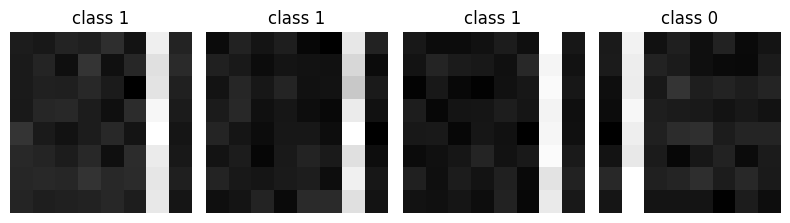

In [2]:
# Build a toy dataset: 8×8 grids with one of two patterns (left-bar vs right-bar).
def make_toy_images(n=1000, seed=0):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, 8, 8), dtype=np.float32)
    y = rng.integers(0, 2, size=n)
    for i, yi in enumerate(y):
        X[i, 0] = rng.normal(0, 0.05, (8, 8))
        col = 1 if yi == 0 else 6
        X[i, 0, :, col] += 1.0     # bright vertical bar at left or right
    return X, y.astype(np.int64)

Xtr_np, ytr_np = make_toy_images(800, seed=0)
Xte_np, yte_np = make_toy_images(200, seed=1)

fig, axes = plt.subplots(1, 4, figsize=(8, 2.2))
for ax, im, lbl in zip(axes, Xtr_np[:4], ytr_np[:4]):
    ax.imshow(im[0], cmap="gray"); ax.set_title(f"class {lbl}"); ax.axis("off")
plt.tight_layout(); plt.show()


In [3]:
if HAS_TORCH:
    class TinyCNN(nn.Module):
        def __init__(self, n_classes=2):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
            self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
            self.pool  = nn.MaxPool2d(2, 2)
            self.fc    = nn.Linear(16 * 2 * 2, n_classes)
        def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))     # → 8×4×4
            x = self.pool(F.relu(self.conv2(x)))     # → 16×2×2
            x = x.flatten(1)
            return self.fc(x)

    cnn = TinyCNN()
    print(cnn); print("params:", sum(p.numel() for p in cnn.parameters()))

    Xtr = torch.from_numpy(Xtr_np); ytr = torch.from_numpy(ytr_np)
    Xte = torch.from_numpy(Xte_np); yte = torch.from_numpy(yte_np)
    dl_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    opt = torch.optim.Adam(cnn.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(8):
        cnn.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(cnn(xb), yb).backward(); opt.step()
        cnn.eval()
        with torch.no_grad():
            acc = (cnn(Xte).argmax(1) == yte).float().mean().item()
        print(f"epoch {epoch}  test acc {acc:.3f}")


**Why a CNN beats an MLP on images.** A CNN reuses the same filter at every location (*weight sharing*) and so has dramatically fewer parameters for the same expressive power. The locality assumption (nearby pixels matter together) is *baked into the architecture*.

For real datasets — CIFAR-10, ImageNet — use a pretrained backbone like `torchvision.models.resnet18(weights="DEFAULT")` and fine-tune. We cover that in A3.


## 2. RNNs — the canonical sequence model

A recurrent layer maintains a hidden state $h_t$ that gets updated as it consumes a sequence:

$$
h_t = f(W_x x_t + W_h h_{t-1} + b)
$$

LSTMs and GRUs are the variants you'll actually use — they have gating that fixes vanishing-gradient issues.

### Toy task — classify whether a sum exceeds a threshold

Each sample is a length-20 sequence of random numbers; the label is 1 if the running sum ever exceeds a cut-off.


In [4]:
def make_seq_data(n=2000, L=20, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, L, 1)).astype(np.float32)
    y = (X.sum(axis=1).squeeze() > 1.5).astype(np.int64)
    return X, y

Xtr_np, ytr_np = make_seq_data(2000, seed=0)
Xte_np, yte_np = make_seq_data(500,  seed=1)
print("balance — train:", float(ytr_np.mean()), "test:", float(yte_np.mean()))


balance — train: 0.3775 test: 0.354


In [5]:
if HAS_TORCH:
    class TinyLSTM(nn.Module):
        def __init__(self, input_dim=1, hidden=32, n_classes=2):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden, batch_first=True)
            self.fc   = nn.Linear(hidden, n_classes)
        def forward(self, x):
            out, (h, c) = self.lstm(x)     # out: (B, L, H), h: (1, B, H)
            return self.fc(h[-1])          # use the final hidden state

    Xtr = torch.from_numpy(Xtr_np); ytr = torch.from_numpy(ytr_np)
    Xte = torch.from_numpy(Xte_np); yte = torch.from_numpy(yte_np)
    dl_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    rnn = TinyLSTM()
    opt = torch.optim.Adam(rnn.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(8):
        rnn.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(rnn(xb), yb).backward(); opt.step()
        rnn.eval()
        with torch.no_grad():
            acc = (rnn(Xte).argmax(1) == yte).float().mean().item()
        print(f"epoch {epoch}  test acc {acc:.3f}")


**Things to know about RNNs**

| Concept | Detail |
|---|---|
| `batch_first=True` | inputs are `(batch, seq, features)`. Off by default — set it! |
| Variable-length sequences | Use `nn.utils.rnn.pack_padded_sequence` |
| Bidirectional | `nn.LSTM(..., bidirectional=True)` doubles the hidden output |
| Truncated BPTT | For very long sequences, detach hidden state across chunks |

⚠️ **Why people moved to Transformers.** RNNs process sequences left-to-right, so they can't be parallelised over time. Transformers compute attention over all positions in parallel — orders of magnitude faster on modern hardware.


## 3. A tiny Transformer encoder

A Transformer block is:

```
x → MultiHeadAttention(x, x, x) → Add & LayerNorm → FFN → Add & LayerNorm
```

`nn.TransformerEncoderLayer` packages this. We just need to add positional encodings and a classification head.


In [6]:
if HAS_TORCH:
    class PositionalEncoding(nn.Module):
        def __init__(self, d_model, max_len=128):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len).unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div)
            pe[:, 1::2] = torch.cos(position * div)
            self.register_buffer("pe", pe)
        def forward(self, x):
            return x + self.pe[: x.size(1)].unsqueeze(0)

    class TinyTransformer(nn.Module):
        def __init__(self, input_dim=1, d_model=32, n_heads=4, n_layers=2, n_classes=2, max_len=64):
            super().__init__()
            self.proj  = nn.Linear(input_dim, d_model)
            self.pe    = PositionalEncoding(d_model, max_len=max_len)
            layer      = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64,
                                                    dropout=0.1, batch_first=True, activation="relu")
            self.enc   = nn.TransformerEncoder(layer, num_layers=n_layers)
            self.head  = nn.Linear(d_model, n_classes)
        def forward(self, x):
            x = self.pe(self.proj(x))           # (B, L, d_model)
            x = self.enc(x)                      # (B, L, d_model)
            return self.head(x.mean(dim=1))     # pool by averaging across sequence

    tx = TinyTransformer()
    print("params:", sum(p.numel() for p in tx.parameters()))

    opt = torch.optim.Adam(tx.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(8):
        tx.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(tx(xb), yb).backward(); opt.step()
        tx.eval()
        with torch.no_grad():
            acc = (tx(Xte).argmax(1) == yte).float().mean().item()
        print(f"epoch {epoch}  test acc {acc:.3f}")


**What the encoder block actually does**

`MultiHeadAttention(x, x, x)` — for each token, compute a weighted sum of *all* other tokens, where the weight is a learned similarity (the *attention score*). The three `x`s are queries, keys, values — *all the same* in self-attention.

`Add & LayerNorm` — the residual connection is what makes deep stacks trainable. Layer-norm stabilises the activations.

`FFN` — a two-layer MLP applied independently per position. This is where most of the parameters live in a typical Transformer.

**Receptive field.** A 2-layer encoder already has *global* receptive field (any token can attend to any other in one step). Compare to a CNN where you need many layers.


## 4. RNN vs Transformer — pick the right tool

| Criterion | LSTM/GRU | Transformer |
|---|---|---|
| Sequence length | OK to ~1000 | Excellent (with attention masks, FlashAttention, etc.) |
| Parallelism in training | Sequential | Parallel across positions |
| Inductive bias | Order matters, recent context emphasised | None until you add positional encodings |
| Sample efficiency on small data | Often better | Worse without pretraining |
| Hardware match (GPUs/TPUs) | Mediocre | Excellent |

**Heuristic.** Small dataset, < 100 timesteps → LSTM is fine. Lots of data, long sequences, GPU available → Transformer. Pretrained model in the wild → almost certainly a Transformer.


## 🧪 Exercises

### Exercise 1 — Augment the CNN
The toy CNN doesn't generalise far. Add **random horizontal shift** as a data augmentation: roll each image by a uniform random amount in [-2, 2] pixels at training time. Does test accuracy stay above 0.9 if you make the bar slightly noisier (`bar value = 0.5` instead of `1.0`)?


In [7]:
if HAS_TORCH:
    # ── Exercise 1 solution ──────────────────────────────────────────────
    def augment_batch(x):
        # x: (B, 1, 8, 8). Roll each sample along width by a random shift.
        rolled = torch.empty_like(x)
        for i in range(x.size(0)):
            s = int(torch.randint(-2, 3, (1,)).item())
            rolled[i] = torch.roll(x[i], shifts=s, dims=-1)
        return rolled

    def make_noisy_images(n=600, seed=0, bar_val=0.5):
        rng = np.random.default_rng(seed)
        X = rng.normal(0, 0.1, (n, 1, 8, 8)).astype(np.float32)
        y = rng.integers(0, 2, size=n)
        for i, yi in enumerate(y):
            col = 1 if yi == 0 else 6
            X[i, 0, :, col] += bar_val
        return X, y.astype(np.int64)

    Xtr_np, ytr_np = make_noisy_images(800, seed=0, bar_val=0.5)
    Xte_np, yte_np = make_noisy_images(200, seed=1, bar_val=0.5)
    Xtr = torch.from_numpy(Xtr_np); ytr = torch.from_numpy(ytr_np)
    Xte = torch.from_numpy(Xte_np); yte = torch.from_numpy(yte_np)

    cnn = TinyCNN(); opt = torch.optim.Adam(cnn.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()
    dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
    for epoch in range(15):
        cnn.train()
        for xb, yb in dl:
            xb_aug = augment_batch(xb)
            opt.zero_grad(); loss_fn(cnn(xb_aug), yb).backward(); opt.step()
    cnn.eval()
    with torch.no_grad():
        acc = (cnn(Xte).argmax(1) == yte).float().mean().item()
    print(f"noisy-bar augmented CNN test acc: {acc:.3f}")


### Exercise 2 — A masked Transformer
The encoder we built can attend to *future* tokens. Modify it to be **causal** (each position only sees positions ≤ itself) using `nn.Transformer.generate_square_subsequent_mask`. Verify the model can no longer "peek" by zeroing the input from position 10 onward and confirming predictions for early positions still work.


In [8]:
if HAS_TORCH:
    # ── Exercise 2 solution ──────────────────────────────────────────────
    class CausalTransformer(nn.Module):
        def __init__(self, input_dim=1, d_model=32, n_heads=4, n_layers=2, max_len=20):
            super().__init__()
            self.proj = nn.Linear(input_dim, d_model)
            self.pe   = PositionalEncoding(d_model, max_len=max_len)
            layer     = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64,
                                                   batch_first=True, activation="relu")
            self.enc  = nn.TransformerEncoder(layer, num_layers=n_layers)
            self.head = nn.Linear(d_model, 2)
            self.max_len = max_len
        def forward(self, x):
            L = x.size(1)
            mask = torch.triu(torch.ones(L, L), diagonal=1).bool()    # True = masked out
            x = self.pe(self.proj(x))
            x = self.enc(x, mask=mask)
            return self.head(x.mean(dim=1))
    ct = CausalTransformer()
    out = ct(torch.from_numpy(Xte_np[:4].reshape(4, 64, 1).astype(np.float32))
             if False else torch.zeros(4, 20, 1))     # smoke test
    print("Causal transformer output shape:", out.shape)


## 🧠 Key takeaways

- **CNNs** trade locality + weight-sharing → far fewer parameters per unit of expressive power on grid data.
- **RNNs (LSTMs)** still shine on small sequence datasets with strong order structure.
- **Transformers** dominate when you have lots of data, long sequences, and a GPU.
- The same training loop drives all three architectures.

## 🚀 Next step

[`A3_pytorch_fine_tuning.ipynb`](./A3_pytorch_fine_tuning.ipynb) — transfer learning: take a *pretrained* small transformer (DistilBERT-class) and fine-tune it for a real classification task.
